<a href="https://colab.research.google.com/github/haniminsyirah/uber-demand-fare-optimization-model/blob/main/Ride_Hailing_analytics_%26_Pricing_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ride-Hailing Analytics & Fare Optimization

View Dasboard : [Link](https://app.powerbi.com/view?r=eyJrIjoiNDY2YWNiYWQtNmZmZS00NWI4LTk5YjMtYTA5ZDEyNzNmYjY3IiwidCI6IjE4Y2U3NmY2LTk5ZjQtNDU3Zi05ZjYyLWFjZDY1ZDliOTc3NyIsImMiOjEwfQ%3D%3D)

#IMPORTING LIBRARIES

In [ ]:
import gdown
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from geopy.distance import geodesic

#for regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import statsmodels.api as sm #for VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor #for VIF


#IMPORTING CSV FILE FROM GOOGLE DRIVE

In [ ]:
url = "https://drive.google.com/file/d/1iY7wagUZmhZohpzESW6OlqEwuEwgwYrI/view?usp=sharing"
output = "uber.csv"
gdown.download(url, output, quiet=False, fuzzy=True)

Downloading...
From: https://drive.google.com/uc?id=1iY7wagUZmhZohpzESW6OlqEwuEwgwYrI
To: /content/uber.csv
100%|██████████| 23.5M/23.5M [00:00<00:00, 130MB/s]


'uber.csv'

In [ ]:
uber = pd.read_csv('/content/uber.csv')
uber

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1


#OVERVIEW

In [ ]:
#check overview all coloumn
uber.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


# DATA CLEANING

##DROP UNUSED COLUMN

Remove unused coloumn, like key coloumn, because we not use this coloumn

In [ ]:
#drop key coloumn
uber.drop('key', axis=1, inplace=True)
uber.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   fare_amount        200000 non-null  float64
 2   pickup_datetime    200000 non-null  object 
 3   pickup_longitude   200000 non-null  float64
 4   pickup_latitude    200000 non-null  float64
 5   dropoff_longitude  199999 non-null  float64
 6   dropoff_latitude   199999 non-null  float64
 7   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 12.2+ MB


##RENAME WRONG NAMED COLUMN

Rename column that has no title to order_id

In [ ]:
#rename unname coloumn to order_id
uber.rename(columns={'Unnamed: 0': 'order_id'}, inplace=True)
uber.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   order_id           200000 non-null  int64  
 1   fare_amount        200000 non-null  float64
 2   pickup_datetime    200000 non-null  object 
 3   pickup_longitude   200000 non-null  float64
 4   pickup_latitude    200000 non-null  float64
 5   dropoff_longitude  199999 non-null  float64
 6   dropoff_latitude   199999 non-null  float64
 7   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 12.2+ MB


##DROP NULL VALUE

We delete null data because we cannot fill in according to our assumptions because the data will be inaccurate

In [ ]:
#check data null value
uber[uber.isnull().any(axis=1)]


,order_id,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
87946,32736015,24.1,2013-07-02 03:51:57 UTC,-73.950581,40.779692,NaN,NaN,0


In [ ]:
#drop data null value
uber.dropna(inplace=True)
uber[uber.isnull().any(axis=1)]

,order_id,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count


Data isnull complete deleted

##CHECK FOR DUPLICATES

In [ ]:
# to check duplicates in general
# there is no duplicate data in all column
uber[uber.duplicated()]

,order_id,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count


In [ ]:
# to check duplicates in primary key
# there is no duplicate in order_id column
uber['order_id'].value_counts()

24238194    1
23286231    1
45197665    1
30631497    1
7869264     1
           ..
53467014    1
15557161    1
11971041    1
6135974     1
11951496    1
Name: order_id, Length: 199999, dtype: int64

#LONGITUDE LATITUDE COLUMNS DATA CLEANING (LIMITED IN NEW YORK AREA)

The latitude and longitude boundaries of New York City can be approximated as follows:

Latitude boundaries:

Southern boundary: Approximately 40.4774 degrees North (bottom of Staten Island).
Northern boundary: Approximately 40.9176 degrees North (top of the Bronx).
Longitude boundaries:

Longitude boundaries:

Western boundary: Approximately -74.2591 degrees East (west side of Staten Island).
Eastern boundary: Approximately -73.7004 degrees East (east side of Queens).

###DROP ZERO VALUE IN LONGITUDE LATITUDE COLUMNS


In [ ]:
#check for zero value in longitude latitude columns
uber.loc[(uber['pickup_longitude'] == 0) | (uber['pickup_latitude'] == 0) | (uber['dropoff_longitude'] == 0) | (uber['dropoff_latitude'] == 0) ]

,order_id,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
7,44195482,2.5,2012-12-11 13:52:00 UTC,0.0,0.0,0.0,0.0,1
11,6379048,8.5,2011-05-23 22:15:00 UTC,0.0,0.0,0.0,0.0,1
65,21993993,6.0,2014-05-05 19:27:00 UTC,0.0,0.0,0.0,0.0,1
92,1454546,6.1,2011-12-02 14:07:00 UTC,0.0,0.0,0.0,0.0,1
120,17358122,6.5,2010-08-20 19:39:48 UTC,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...
199718,49162936,4.9,2011-08-19 07:16:00 UTC,0.0,0.0,0.0,0.0,1
199724,46007628,7.5,2013-10-11 11:25:41 UTC,0.0,0.0,0.0,0.0,1
199880,35013970,6.5,2014-02-22 06:45:46 UTC,0.0,0.0,0.0,0.0,1
199883,44115598,12.5,2012-09-10 17:39:00 UTC,0.0,0.0,0.0,0.0,2


In [ ]:
#drop the for zero value in longitude latitude columns
uber = uber.loc[~((uber['pickup_longitude'] == 0) | (uber['pickup_latitude'] == 0) | (uber['dropoff_longitude'] == 0) | (uber['dropoff_latitude'] == 0))]
uber.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 196031 entries, 0 to 199999
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   order_id           196031 non-null  int64  
 1   fare_amount        196031 non-null  float64
 2   pickup_datetime    196031 non-null  object 
 3   pickup_longitude   196031 non-null  float64
 4   pickup_latitude    196031 non-null  float64
 5   dropoff_longitude  196031 non-null  float64
 6   dropoff_latitude   196031 non-null  float64
 7   passenger_count    196031 non-null  int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 13.5+ MB


###SWITCH THE SWITCHED VALUES IN LONGITUDE AND LATITUDE COLUMNS

we found in the data that there are several rows that the longitude and latitude value are switched, so we need to switched it to the right column

In [ ]:
#to find the switched values
uber_geo_switched = uber[((uber['pickup_latitude']>-74.2591) & (uber['pickup_latitude']<-73.7004)) |
                  ((uber['dropoff_latitude']>-74.2591) & (uber['dropoff_latitude']<-73.7004)) |
                  ((uber['pickup_longitude']>40.4774) & (uber['pickup_longitude']<40.9176)) |
                  ((uber['dropoff_longitude']>40.4774) & (uber['dropoff_longitude']<40.9176)) ]
uber_geo_switched

,order_id,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
2497,6452891,6.00,2013-05-22 10:54:00 UTC,40.746760,-73.982127,40.757287,-73.974800,1
4376,44648183,12.50,2013-05-24 00:43:00 UTC,40.751797,-73.970777,40.719787,-73.992137,6
4424,3826665,9.50,2013-05-25 01:16:00 UTC,40.732897,-73.997740,40.747532,-73.972540,1
4747,52635142,6.50,2013-05-22 12:38:00 UTC,40.770667,-73.961957,40.761672,-73.967237,1
7367,45851743,10.50,2013-05-23 00:29:00 UTC,40.714897,-74.009697,40.726197,-73.994370,2
...,...,...,...,...,...,...,...,...
184570,22770548,9.00,2013-05-25 14:57:00 UTC,40.803672,-73.967302,40.778370,-73.982230,1
185317,10051528,10.50,2013-05-22 14:43:00 UTC,40.806012,-73.942590,40.785075,-73.957792,1
189045,6364125,42.33,2013-05-24 00:35:00 UTC,40.771465,-73.875495,40.755835,-73.978210,6
190154,36869885,57.33,2013-05-23 15:55:00 UTC,40.644182,-73.787107,40.796397,-73.975535,1


In [ ]:
#to switch the switched value in new dataframe

switch = uber_geo_switched.index

for pickup_row in switch:
    pickup_temp_value = uber_geo_switched.at[pickup_row, 'pickup_longitude']
    uber_geo_switched.at[pickup_row, 'pickup_longitude'] = uber_geo_switched.at[pickup_row, 'pickup_latitude']
    uber_geo_switched.at[pickup_row, 'pickup_latitude'] = pickup_temp_value

for dropoff_row in switch:
    dropoff_temp_value = uber_geo_switched.at[dropoff_row, 'dropoff_longitude']
    uber_geo_switched.at[dropoff_row, 'dropoff_longitude'] = uber_geo_switched.at[dropoff_row, 'dropoff_latitude']
    uber_geo_switched.at[dropoff_row, 'dropoff_latitude'] = dropoff_temp_value

uber_geo_switched

,order_id,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
2497,6452891,6.00,2013-05-22 10:54:00 UTC,-73.982127,40.746760,-73.974800,40.757287,1
4376,44648183,12.50,2013-05-24 00:43:00 UTC,-73.970777,40.751797,-73.992137,40.719787,6
4424,3826665,9.50,2013-05-25 01:16:00 UTC,-73.997740,40.732897,-73.972540,40.747532,1
4747,52635142,6.50,2013-05-22 12:38:00 UTC,-73.961957,40.770667,-73.967237,40.761672,1
7367,45851743,10.50,2013-05-23 00:29:00 UTC,-74.009697,40.714897,-73.994370,40.726197,2
...,...,...,...,...,...,...,...,...
184570,22770548,9.00,2013-05-25 14:57:00 UTC,-73.967302,40.803672,-73.982230,40.778370,1
185317,10051528,10.50,2013-05-22 14:43:00 UTC,-73.942590,40.806012,-73.957792,40.785075,1
189045,6364125,42.33,2013-05-24 00:35:00 UTC,-73.875495,40.771465,-73.978210,40.755835,6
190154,36869885,57.33,2013-05-23 15:55:00 UTC,-73.787107,40.644182,-73.975535,40.796397,1


In [ ]:
#to copy intial dataframe
uber2 = uber.copy()

#drop the rows of switched value in copied initial dataframe
uber2.drop(uber_geo_switched.index,inplace=True)

#union the new data frame (that the switched value of longitude and latitude columns had been switched) to the copied initial dataframe
uber2 = pd.concat([uber2, uber_geo_switched])

uber2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 196031 entries, 0 to 193339
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   order_id           196031 non-null  int64  
 1   fare_amount        196031 non-null  float64
 2   pickup_datetime    196031 non-null  object 
 3   pickup_longitude   196031 non-null  float64
 4   pickup_latitude    196031 non-null  float64
 5   dropoff_longitude  196031 non-null  float64
 6   dropoff_latitude   196031 non-null  float64
 7   passenger_count    196031 non-null  int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 13.5+ MB


In [ ]:
#to re-check the original switched value in initial dataframe with switched value condition
uber[((uber['pickup_latitude']>-74.2591) & (uber['pickup_latitude']<-73.7004)) |
    ((uber['dropoff_latitude']>-74.2591) & (uber['dropoff_latitude']<-73.7004)) |
    ((uber['pickup_longitude']>40.4774) & (uber['pickup_longitude']<40.9176)) |
    ((uber['dropoff_longitude']>40.4774) & (uber['dropoff_longitude']<40.9176)) ]

,order_id,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
2497,6452891,6.00,2013-05-22 10:54:00 UTC,40.746760,-73.982127,40.757287,-73.974800,1
4376,44648183,12.50,2013-05-24 00:43:00 UTC,40.751797,-73.970777,40.719787,-73.992137,6
4424,3826665,9.50,2013-05-25 01:16:00 UTC,40.732897,-73.997740,40.747532,-73.972540,1
4747,52635142,6.50,2013-05-22 12:38:00 UTC,40.770667,-73.961957,40.761672,-73.967237,1
7367,45851743,10.50,2013-05-23 00:29:00 UTC,40.714897,-74.009697,40.726197,-73.994370,2
...,...,...,...,...,...,...,...,...
184570,22770548,9.00,2013-05-25 14:57:00 UTC,40.803672,-73.967302,40.778370,-73.982230,1
185317,10051528,10.50,2013-05-22 14:43:00 UTC,40.806012,-73.942590,40.785075,-73.957792,1
189045,6364125,42.33,2013-05-24 00:35:00 UTC,40.771465,-73.875495,40.755835,-73.978210,6
190154,36869885,57.33,2013-05-23 15:55:00 UTC,40.644182,-73.787107,40.796397,-73.975535,1


In [ ]:
#with the same syntax, it will check whether the columns with the same condition as the previous syntax have been deleted
uber2[((uber2['pickup_latitude']>-74.2591) & (uber2['pickup_latitude']<-73.7004)) |
    ((uber2['dropoff_latitude']>-74.2591) & (uber2['dropoff_latitude']<-73.7004)) |
    ((uber2['pickup_longitude']>40.4774) & (uber2['pickup_longitude']<40.9176)) |
    ((uber2['dropoff_longitude']>40.4774) & (uber2['dropoff_longitude']<40.9176)) ]

,order_id,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count


In [ ]:
#to check if the switched values have been switched
uber2[uber2.index.isin(uber_geo_switched.index)]

,order_id,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
2497,6452891,6.00,2013-05-22 10:54:00 UTC,-73.982127,40.746760,-73.974800,40.757287,1
4376,44648183,12.50,2013-05-24 00:43:00 UTC,-73.970777,40.751797,-73.992137,40.719787,6
4424,3826665,9.50,2013-05-25 01:16:00 UTC,-73.997740,40.732897,-73.972540,40.747532,1
4747,52635142,6.50,2013-05-22 12:38:00 UTC,-73.961957,40.770667,-73.967237,40.761672,1
7367,45851743,10.50,2013-05-23 00:29:00 UTC,-74.009697,40.714897,-73.994370,40.726197,2
...,...,...,...,...,...,...,...,...
184570,22770548,9.00,2013-05-25 14:57:00 UTC,-73.967302,40.803672,-73.982230,40.778370,1
185317,10051528,10.50,2013-05-22 14:43:00 UTC,-73.942590,40.806012,-73.957792,40.785075,1
189045,6364125,42.33,2013-05-24 00:35:00 UTC,-73.875495,40.771465,-73.978210,40.755835,6
190154,36869885,57.33,2013-05-23 15:55:00 UTC,-73.787107,40.644182,-73.975535,40.796397,1


###DROP THE BOOKING ORDER DATA OUTSIDE NEW YORK

Because the data itself shows overall in New York, so, we need to remove the data that are outside New York area

In [ ]:
#to see the booking order data that happened outside the New York
uber_geo_delete = uber2[(uber2['pickup_latitude']>40.9176) | (uber2['pickup_latitude']<40.4774)|
                  (uber2['dropoff_latitude']>40.9176) | (uber2['dropoff_latitude']<40.4774)|
                  (uber2['pickup_longitude']>-73.7004) | (uber2['pickup_longitude']<-74.2591) |
                  (uber2['dropoff_longitude']>-73.7004) | (uber2['dropoff_longitude']<-74.2591)]
uber_geo_delete

,order_id,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
169,17269533,14.5,2010-07-14 17:38:00 UTC,0.001782,0.007380,0.000875,0.005670,1
696,46776557,5.3,2011-02-05 17:52:56 UTC,-74.689831,40.190564,-74.689831,40.190564,1
1738,41396796,12.9,2010-03-12 18:42:00 UTC,-73.867800,40.966745,-73.855478,40.960380,1
1905,6368561,5.0,2012-10-19 20:24:00 UTC,-73.733760,40.221474,-73.737622,40.223950,1
1945,915515,7.0,2013-02-10 16:18:00 UTC,-0.131667,40.757063,-73.991593,40.749953,1
...,...,...,...,...,...,...,...,...
197695,39278141,7.3,2012-01-23 23:52:00 UTC,-73.573012,40.350780,-73.548835,40.358117,2
198412,22243974,9.7,2012-04-24 11:57:00 UTC,-73.334337,42.223633,-73.464092,42.273158,1
199403,26201357,7.0,2013-01-20 17:58:29 UTC,-67.370360,39.999790,-73.971058,40.753000,1
199641,50369727,8.1,2012-06-22 12:36:00 UTC,-74.000143,40.742877,-7.995197,40.759382,5


In [ ]:
#to drop the booking order data that happened outside the New York
uber2.drop(uber_geo_delete.index,inplace=True)
uber2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 195628 entries, 0 to 193339
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   order_id           195628 non-null  int64  
 1   fare_amount        195628 non-null  float64
 2   pickup_datetime    195628 non-null  object 
 3   pickup_longitude   195628 non-null  float64
 4   pickup_latitude    195628 non-null  float64
 5   dropoff_longitude  195628 non-null  float64
 6   dropoff_latitude   195628 non-null  float64
 7   passenger_count    195628 non-null  int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 13.4+ MB


In [ ]:
#to check wheter the data had been dropped
uber2[uber2.index.isin(uber_geo_delete.index)]

,order_id,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count


In [ ]:
#to recheck the result in longitude latitude data cleaning
uber2.describe()

,order_id,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,1.956280e+05,195628.000000,195628.000000,195628.000000,195628.000000,195628.000000,195628.000000
mean,2.770948e+07,11.292354,-73.975513,40.750782,-73.974598,40.751048,1.685290
std,1.600935e+07,9.515018,0.034477,0.026937,0.034056,0.030682,1.388399
min,1.000000e+00,-52.000000,-74.243432,40.498988,-74.257692,40.486242,0.000000
25%,1.382693e+07,6.000000,-73.992277,40.736464,-73.991600,40.735340,1.000000
50%,2.774660e+07,8.500000,-73.982117,40.753300,-73.980557,40.753737,1.000000
75%,4.154159e+07,12.500000,-73.968410,40.767517,-73.965471,40.768307,2.000000
max,5.542357e+07,499.000000,-73.702735,40.917048,-73.700650,40.916956,208.000000


##MAKE A GROUPING BY GRID OF 1 KM (FOR HIGH DEMAND PICKUP LONGITUDE AND LATITUDE)

Grouping the data for High demand area by grid per 1 KM

In [ ]:
#make new function to grid the new york area by 1 km-square
def assign_to_grid_center(longitude, latitude):
    grid_size = 0.009  # Approx. 1km in degrees (Adjust this based on your area)
    grid_longitude = round(longitude / grid_size) * grid_size + grid_size / 2
    grid_latitude = round(latitude / grid_size) * grid_size + grid_size / 2
    return grid_longitude, grid_latitude

In [ ]:
#make new column to group each order to specific grid location
uber2['pickup_longitude_grid'], uber2['pickup_latitude_grid'] = zip(*uber2.apply(lambda row: assign_to_grid_center(row['pickup_longitude'], row['pickup_latitude']), axis=1))

In [ ]:
uber2.head()

,order_id,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_longitude_grid,pickup_latitude_grid
0,24238194,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1,-73.9935,40.7385
1,27835199,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1,-73.9935,40.7295
2,44984355,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1,-74.0025,40.7475
3,25894730,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3,-73.9755,40.7925
4,17610152,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5,-73.9215,40.7475


In [ ]:
uber2[['pickup_longitude_grid','pickup_latitude_grid']].value_counts()

pickup_longitude_grid  pickup_latitude_grid
-73.9665               40.7655                 9854
-73.9845               40.7565                 9477
-73.9755               40.7655                 8385
                       40.7565                 8081
-73.9845               40.7475                 7056
                                               ... 
-73.9665               40.6125                    1
                       40.5945                    1
                       40.5855                    1
-73.9755               40.8645                    1
-73.6965               40.7565                    1
Length: 732, dtype: int64

##MAKE A BIGGER GROUPING BY GRID AREA OF 7.5KM

In [ ]:
#make new function to grid the new york area by 7.5 km-square
def assign_to_bigger_grid_center(longitude, latitude):
    grid_size = 0.075  # Approx. 7.5km in degrees (Adjust this based on your area)
    grid_longitude = round(longitude / grid_size) * grid_size + grid_size / 2
    grid_latitude = round(latitude / grid_size) * grid_size + grid_size / 2
    return grid_longitude, grid_latitude

In [ ]:
#make new column to group each order to specific grid location
uber2['big_pickup_longitude_grid'], uber2['big_pickup_latitude_grid'] = zip(*uber2.apply(lambda row: assign_to_bigger_grid_center(row['pickup_longitude'], row['pickup_latitude']), axis=1))
uber2.head()

,order_id,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_longitude_grid,pickup_latitude_grid,big_pickup_longitude_grid,big_pickup_latitude_grid
0,24238194,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1,-73.9935,40.7385,-73.9875,40.7625
1,27835199,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1,-73.9935,40.7295,-73.9875,40.7625
2,44984355,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1,-74.0025,40.7475,-73.9875,40.7625
3,25894730,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3,-73.9755,40.7925,-73.9125,40.8375
4,17610152,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5,-73.9215,40.7475,-73.9125,40.7625


In [ ]:
#to check the value counts of pickup bigger grid
uber2[['big_pickup_longitude_grid','big_pickup_latitude_grid']].value_counts()

big_pickup_longitude_grid  big_pickup_latitude_grid
-73.9875                   40.7625                     68363
-73.9125                   40.8375                     57602
                           40.7625                     56397
-73.8375                   40.8375                      4073
-73.9875                   40.8375                      3487
-73.7625                   40.6875                      3082
-73.9125                   40.6875                       847
-73.8375                   40.7625                       579
-73.9875                   40.6875                       570
-73.9125                   40.9125                       176
-73.7625                   40.7625                       153
-73.8375                   40.9125                        58
                           40.6875                        40
-73.7625                   40.8375                        28
-73.9125                   40.6125                        24
-74.1375                   40.762

In [ ]:
#to check the data type
uber2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 195628 entries, 0 to 193339
Data columns (total 12 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   order_id                   195628 non-null  int64  
 1   fare_amount                195628 non-null  float64
 2   pickup_datetime            195628 non-null  object 
 3   pickup_longitude           195628 non-null  float64
 4   pickup_latitude            195628 non-null  float64
 5   dropoff_longitude          195628 non-null  float64
 6   dropoff_latitude           195628 non-null  float64
 7   passenger_count            195628 non-null  int64  
 8   pickup_longitude_grid      195628 non-null  float64
 9   pickup_latitude_grid       195628 non-null  float64
 10  big_pickup_longitude_grid  195628 non-null  float64
 11  big_pickup_latitude_grid   195628 non-null  float64
dtypes: float64(9), int64(2), object(1)
memory usage: 19.4+ MB


In [ ]:
#we have to round it because it is a float data type, so the decimal could be really long and it cant be used by "==" function

# List of columns to round
columns_to_round = ['big_pickup_longitude_grid', 'big_pickup_latitude_grid']

# Number of decimal places to round to
decimal_places = 4

# Round the specified columns to the specified decimal places
uber2[columns_to_round] = uber2[columns_to_round].round(decimal_places)

In [ ]:
#make neww column of the bigger pickup area
uber2['approx_pickup_area'] = 'other_area'
uber2.loc[(uber2['big_pickup_longitude_grid'] == -73.9875) & (uber2['big_pickup_latitude_grid'] == 40.7625), 'approx_pickup_area'] = 'manhattan'
uber2.loc[(uber2['big_pickup_longitude_grid'] == -73.9125) & (uber2['big_pickup_latitude_grid'] == 40.8375), 'approx_pickup_area'] = 'bronx'
uber2.loc[(uber2['big_pickup_longitude_grid'] == -73.9125) & (uber2['big_pickup_latitude_grid'] == 40.7625), 'approx_pickup_area'] = 'queens'
uber2.head()

,order_id,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_longitude_grid,pickup_latitude_grid,big_pickup_longitude_grid,big_pickup_latitude_grid,approx_pickup_area
0,24238194,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1,-73.9935,40.7385,-73.9875,40.7625,manhattan
1,27835199,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1,-73.9935,40.7295,-73.9875,40.7625,manhattan
2,44984355,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1,-74.0025,40.7475,-73.9875,40.7625,manhattan
3,25894730,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3,-73.9755,40.7925,-73.9125,40.8375,bronx
4,17610152,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5,-73.9215,40.7475,-73.9125,40.7625,queens


In [ ]:
#check the new columns values
uber2['approx_pickup_area'].value_counts()

manhattan     68363
bronx         57602
queens        56397
other_area    13266
Name: approx_pickup_area, dtype: int64

#MAKE NEW COLUMN THAT DETERMINE THE DISTANCE


In [ ]:
# Define a function to calculate the distance between two points
def calculate_distance(row):
    pickup_coords = (row['pickup_latitude'], row['pickup_longitude'])
    dropoff_coords = (row['dropoff_latitude'], row['dropoff_longitude'])
    return geodesic(pickup_coords, dropoff_coords).miles

# Calculate distance for each row in the DataFrame and create a new column named 'distance_km'
uber2['distance_miles'] = uber2.apply(calculate_distance, axis=1)

uber2

,order_id,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_longitude_grid,pickup_latitude_grid,big_pickup_longitude_grid,big_pickup_latitude_grid,approx_pickup_area,distance_miles
0,24238194,7.50,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1,-73.9935,40.7385,-73.9875,40.7625,manhattan,1.044594
1,27835199,7.70,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1,-73.9935,40.7295,-73.9875,40.7625,manhattan,1.525071
2,44984355,12.90,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1,-74.0025,40.7475,-73.9875,40.7625,manhattan,3.131464
3,25894730,5.30,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3,-73.9755,40.7925,-73.9125,40.8375,bronx,1.032372
4,17610152,16.00,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5,-73.9215,40.7475,-73.9125,40.7625,queens,2.786061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184570,22770548,9.00,2013-05-25 14:57:00 UTC,-73.967302,40.803672,-73.982230,40.778370,1,-73.9665,40.8105,-73.9125,40.8375,bronx,1.913410
185317,10051528,10.50,2013-05-22 14:43:00 UTC,-73.942590,40.806012,-73.957792,40.785075,1,-73.9395,40.8105,-73.9125,40.8375,bronx,1.650074
189045,6364125,42.33,2013-05-24 00:35:00 UTC,-73.875495,40.771465,-73.978210,40.755835,6,-73.8675,40.7745,-73.8375,40.8375,other_area,5.495855
190154,36869885,57.33,2013-05-23 15:55:00 UTC,-73.787107,40.644182,-73.975535,40.796397,1,-73.7865,40.6485,-73.7625,40.6875,other_area,14.428311


#DROP THE UNUSUAL DATA
* PASSENGER COUNT <= 0 (because it is impossible if we have 0 or <0 passenger)
* DISTANCE < 0.05 km (because the distance is too short so we set the threshold of 0.05 km / 50 meters)
* FARE AMOUNT <= 0.1 (because the price is too low and impossible to order uber for free, and in the dataframe there is on 1 booking that have value between 0 - 2.5 dollars)
* PASSENGER COUNT > 7 (because the 3 seats car can contain 7 passenger and 1 driver)

In [ ]:
#to check unusual value from data
uber2.describe()

,order_id,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_longitude_grid,pickup_latitude_grid,big_pickup_longitude_grid,big_pickup_latitude_grid,distance_miles
count,1.956280e+05,195628.000000,195628.000000,195628.000000,195628.000000,195628.000000,195628.000000,195628.000000,195628.000000,195628.000000,195628.000000,195628.000000
mean,2.770948e+07,11.292354,-73.975513,40.750782,-73.974598,40.751048,1.685290,-73.970943,40.755249,-73.935989,40.785906,2.055892
std,1.600935e+07,9.515018,0.034477,0.026937,0.034056,0.030682,1.388399,0.034662,0.027003,0.045469,0.038681,2.212032
min,1.000000e+00,-52.000000,-74.243432,40.498988,-74.257692,40.486242,0.000000,-74.236500,40.504500,-74.212500,40.537500,0.000000
25%,1.382693e+07,6.000000,-73.992277,40.736464,-73.991600,40.735340,1.000000,-73.984500,40.738500,-73.987500,40.762500,0.781171
50%,2.774660e+07,8.500000,-73.982117,40.753300,-73.980557,40.753737,1.000000,-73.975500,40.756500,-73.912500,40.762500,1.340315
75%,4.154159e+07,12.500000,-73.968410,40.767517,-73.965471,40.768307,2.000000,-73.966500,40.774500,-73.912500,40.837500,2.425451
max,5.542357e+07,499.000000,-73.702735,40.917048,-73.700650,40.916956,208.000000,-73.696500,40.918500,-73.687500,40.987500,21.965510


In [ ]:
#to drop the unusual value
uber2.drop(uber2[(uber2['passenger_count']<=0) | (uber2['distance_miles']<0.03) | (uber2['fare_amount']<0.1) | (uber2['passenger_count']>7)].index,inplace=True)

#to check whether the unusual values had been dropped
uber2.describe()

,order_id,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_longitude_grid,pickup_latitude_grid,big_pickup_longitude_grid,big_pickup_latitude_grid,distance_miles
count,1.921280e+05,192128.000000,192128.000000,192128.000000,192128.000000,192128.000000,192128.000000,192128.000000,192128.000000,192128.000000,192128.000000,192128.000000
mean,2.770585e+07,11.287568,-73.975718,40.750866,-73.974791,40.751134,1.690623,-73.971148,40.755332,-73.936182,40.786005,2.086538
std,1.600839e+07,9.330339,0.033992,0.026669,0.033571,0.030502,1.306068,0.034176,0.026734,0.045164,0.038529,2.215113
min,1.000000e+00,2.500000,-74.243432,40.498988,-74.257692,40.486242,1.000000,-74.236500,40.504500,-74.212500,40.537500,0.030153
25%,1.382067e+07,6.000000,-73.992283,40.736515,-73.991602,40.735402,1.000000,-73.984500,40.738500,-73.987500,40.762500,0.802476
50%,2.774014e+07,8.500000,-73.982150,40.753317,-73.980598,40.753766,1.000000,-73.975500,40.756500,-73.912500,40.762500,1.360275
75%,4.153456e+07,12.500000,-73.968571,40.767552,-73.965698,40.768327,2.000000,-73.966500,40.774500,-73.912500,40.837500,2.452389
max,5.542357e+07,220.000000,-73.702735,40.917048,-73.700650,40.916956,6.000000,-73.696500,40.918500,-73.687500,40.987500,21.965510


#CHANGE DATA TYPE


In [ ]:
#to change column to string
uber2['order_id'] = uber2['order_id'].astype('str')

#to check the changed column
uber2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 192128 entries, 0 to 193339
Data columns (total 14 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   order_id                   192128 non-null  object 
 1   fare_amount                192128 non-null  float64
 2   pickup_datetime            192128 non-null  object 
 3   pickup_longitude           192128 non-null  float64
 4   pickup_latitude            192128 non-null  float64
 5   dropoff_longitude          192128 non-null  float64
 6   dropoff_latitude           192128 non-null  float64
 7   passenger_count            192128 non-null  int64  
 8   pickup_longitude_grid      192128 non-null  float64
 9   pickup_latitude_grid       192128 non-null  float64
 10  big_pickup_longitude_grid  192128 non-null  float64
 11  big_pickup_latitude_grid   192128 non-null  float64
 12  approx_pickup_area         192128 non-null  object 
 13  distance_miles             19

In [ ]:
#to change column to datetime
uber2['pickup_datetime'] = pd.to_datetime(uber2['pickup_datetime'], format='%Y-%m-%d %H:%M:%S %Z')

#to check the changed column
uber2.head()

,order_id,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_longitude_grid,pickup_latitude_grid,big_pickup_longitude_grid,big_pickup_latitude_grid,approx_pickup_area,distance_miles
0,24238194,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,-73.9935,40.7385,-73.9875,40.7625,manhattan,1.044594
1,27835199,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,-73.9935,40.7295,-73.9875,40.7625,manhattan,1.525071
2,44984355,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,-74.0025,40.7475,-73.9875,40.7625,manhattan,3.131464
3,25894730,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,-73.9755,40.7925,-73.9125,40.8375,bronx,1.032372
4,17610152,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,-73.9215,40.7475,-73.9125,40.7625,queens,2.786061


#DATETIME DATA CLEANING

In [ ]:
## New York is in UTC-4, so we have to change the date time from UTC+0 to UTC-4

## import library to change the UTC
#import pytz

## Define the UTC-4 (EDT) time zone
#utc_minus_4_timezone = pytz.timezone('US/Eastern')

## Convert the 'pickup_datetime' column to UTC-4 (Eastern Daylight Time)
#uber2['pickup_datetime'] = uber2['pickup_datetime'].dt.tz_convert(utc_minus_4_timezone)

## Print the updated DataFrame
#uber2.head()

In [ ]:
##to check the changed UTC format
#uber2.info()

##CREATING NEW COLUMN ONLY CONSIST OF DATE(YYYY-MM-DD), YEAR (YYYY), MONTH NAME, AND DAY NAME

In [ ]:
# Create a new date column the consist only YYYY-MM-DD
uber2['pickup_date'] = uber2['pickup_datetime'].dt.date

# Change the column type to be datetime
uber2['pickup_date'] = pd.to_datetime(uber2['pickup_date'])

#to check the new column
uber2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 192128 entries, 0 to 193339
Data columns (total 15 columns):
 #   Column                     Non-Null Count   Dtype              
---  ------                     --------------   -----              
 0   order_id                   192128 non-null  object             
 1   fare_amount                192128 non-null  float64            
 2   pickup_datetime            192128 non-null  datetime64[ns, UTC]
 3   pickup_longitude           192128 non-null  float64            
 4   pickup_latitude            192128 non-null  float64            
 5   dropoff_longitude          192128 non-null  float64            
 6   dropoff_latitude           192128 non-null  float64            
 7   passenger_count            192128 non-null  int64              
 8   pickup_longitude_grid      192128 non-null  float64            
 9   pickup_latitude_grid       192128 non-null  float64            
 10  big_pickup_longitude_grid  192128 non-null  float64     

In [ ]:
#to create columns consist of only month, year, and day name
uber2['pickup_day'] = uber2['pickup_datetime'].dt.day_name()
uber2['pickup_month'] = uber2['pickup_datetime'].dt.month_name()
uber2['pickup_year'] = uber2['pickup_datetime'].dt.year

In [ ]:
#to check the new column data type
uber2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 192128 entries, 0 to 193339
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype              
---  ------                     --------------   -----              
 0   order_id                   192128 non-null  object             
 1   fare_amount                192128 non-null  float64            
 2   pickup_datetime            192128 non-null  datetime64[ns, UTC]
 3   pickup_longitude           192128 non-null  float64            
 4   pickup_latitude            192128 non-null  float64            
 5   dropoff_longitude          192128 non-null  float64            
 6   dropoff_latitude           192128 non-null  float64            
 7   passenger_count            192128 non-null  int64              
 8   pickup_longitude_grid      192128 non-null  float64            
 9   pickup_latitude_grid       192128 non-null  float64            
 10  big_pickup_longitude_grid  192128 non-null  float64     

In [ ]:
#to check the date frame
uber2.head()

,order_id,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_longitude_grid,pickup_latitude_grid,big_pickup_longitude_grid,big_pickup_latitude_grid,approx_pickup_area,distance_miles,pickup_date,pickup_day,pickup_month,pickup_year
0,24238194,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,-73.9935,40.7385,-73.9875,40.7625,manhattan,1.044594,2015-05-07,Thursday,May,2015
1,27835199,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,-73.9935,40.7295,-73.9875,40.7625,manhattan,1.525071,2009-07-17,Friday,July,2009
2,44984355,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,-74.0025,40.7475,-73.9875,40.7625,manhattan,3.131464,2009-08-24,Monday,August,2009
3,25894730,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,-73.9755,40.7925,-73.9125,40.8375,bronx,1.032372,2009-06-26,Friday,June,2009
4,17610152,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,-73.9215,40.7475,-73.9125,40.7625,queens,2.786061,2014-08-28,Thursday,August,2014


##CREATING NEW COLUMN CONSIST OF HOUR GROUPING (PER 3 HOURS)

In [ ]:
#to create new column consist of hour grouping (per 3 hours)
uber2.loc[(uber2['pickup_datetime'].dt.hour >= 0) & (uber2['pickup_datetime'].dt.hour < 3), 'hour_group'] = '00.00-03.00'
uber2.loc[(uber2['pickup_datetime'].dt.hour >= 3) & (uber2['pickup_datetime'].dt.hour < 6), 'hour_group'] = '03.00-06.00'
uber2.loc[(uber2['pickup_datetime'].dt.hour >= 6) & (uber2['pickup_datetime'].dt.hour < 9), 'hour_group'] = '06.00-09.00'
uber2.loc[(uber2['pickup_datetime'].dt.hour >= 9) & (uber2['pickup_datetime'].dt.hour < 12), 'hour_group'] = '09.00-12.00'
uber2.loc[(uber2['pickup_datetime'].dt.hour >= 12) & (uber2['pickup_datetime'].dt.hour < 15), 'hour_group'] = '12.00-15.00'
uber2.loc[(uber2['pickup_datetime'].dt.hour >= 15) & (uber2['pickup_datetime'].dt.hour < 18), 'hour_group'] = '15.00-18.00'
uber2.loc[(uber2['pickup_datetime'].dt.hour >= 18) & (uber2['pickup_datetime'].dt.hour < 21), 'hour_group'] = '18.00-21.00'
uber2.loc[(uber2['pickup_datetime'].dt.hour >= 21) & (uber2['pickup_datetime'].dt.hour <24), 'hour_group'] = '21.00-00.00'

In [ ]:
#to check the hour and time grouping
uber2.head()

,order_id,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_longitude_grid,pickup_latitude_grid,big_pickup_longitude_grid,big_pickup_latitude_grid,approx_pickup_area,distance_miles,pickup_date,pickup_day,pickup_month,pickup_year,hour_group
0,24238194,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,-73.9935,40.7385,-73.9875,40.7625,manhattan,1.044594,2015-05-07,Thursday,May,2015,18.00-21.00
1,27835199,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,-73.9935,40.7295,-73.9875,40.7625,manhattan,1.525071,2009-07-17,Friday,July,2009,18.00-21.00
2,44984355,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,-74.0025,40.7475,-73.9875,40.7625,manhattan,3.131464,2009-08-24,Monday,August,2009,21.00-00.00
3,25894730,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,-73.9755,40.7925,-73.9125,40.8375,bronx,1.032372,2009-06-26,Friday,June,2009,06.00-09.00
4,17610152,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,-73.9215,40.7475,-73.9125,40.7625,queens,2.786061,2014-08-28,Thursday,August,2014,15.00-18.00


##AM/PM

In [ ]:
#to create new column consist of hour grouping (per 3 hours)
uber2.loc[(uber2['pickup_datetime'].dt.hour >= 0) & (uber2['pickup_datetime'].dt.hour < 12), 'time_group'] = 'AM'
uber2.loc[(uber2['pickup_datetime'].dt.hour >= 12) & (uber2['pickup_datetime'].dt.hour <24), 'time_group'] = 'PM'
uber2['time_group'].value_counts()

PM    121117
AM     71011
Name: time_group, dtype: int64

#DISTANCE GROUPING

In [ ]:
distance_max = uber2['distance_miles'].max()
bins = [0, 1.25, distance_max] #to devide the bin
labels = ['short_trip', 'long_trip'] #for naming the label for each grouping

uber2['distance_group'] = pd.cut(uber2['distance_miles'], bins=bins, labels=labels, include_lowest=True) #to make a new column of grouping
uber2['distance_group'].value_counts()  #to check the new column of  grouping

long_trip     104164
short_trip     87964
Name: distance_group, dtype: int64

#CHECKING THE VALUES AFTER DATA CLEANING

In [ ]:
uber2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 192128 entries, 0 to 193339
Data columns (total 21 columns):
 #   Column                     Non-Null Count   Dtype              
---  ------                     --------------   -----              
 0   order_id                   192128 non-null  object             
 1   fare_amount                192128 non-null  float64            
 2   pickup_datetime            192128 non-null  datetime64[ns, UTC]
 3   pickup_longitude           192128 non-null  float64            
 4   pickup_latitude            192128 non-null  float64            
 5   dropoff_longitude          192128 non-null  float64            
 6   dropoff_latitude           192128 non-null  float64            
 7   passenger_count            192128 non-null  int64              
 8   pickup_longitude_grid      192128 non-null  float64            
 9   pickup_latitude_grid       192128 non-null  float64            
 10  big_pickup_longitude_grid  192128 non-null  float64     

In [ ]:
for col_uber2 in uber2.columns:
  print(([col_uber2]))
  print(uber2[col_uber2].value_counts())
  print('\n')

['order_id']
24238194    1
15869181    1
25735100    1
28826394    1
2981597     1
           ..
45092387    1
1909264     1
28956520    1
20865334    1
37780326    1
Name: order_id, Length: 192128, dtype: int64


['fare_amount']
6.50     9351
4.50     7922
8.50     7294
5.70     5597
5.30     5593
         ... 
12.27       1
15.15       1
39.39       1
48.90       1
89.10       1
Name: fare_amount, Length: 1125, dtype: int64


['pickup_datetime']
2014-04-13 18:19:00+00:00    4
2010-03-14 12:00:00+00:00    4
2009-02-12 12:46:00+00:00    4
2011-05-04 18:09:00+00:00    3
2009-07-31 20:12:00+00:00    3
                            ..
2009-10-23 19:42:13+00:00    1
2013-06-07 06:35:41+00:00    1
2010-06-05 14:34:00+00:00    1
2009-05-12 18:23:08+00:00    1
2013-05-24 22:11:00+00:00    1
Name: pickup_datetime, Length: 189026, dtype: int64


['pickup_longitude']
-73.982017    20
-73.981397    20
-73.982192    20
-73.982210    20
-73.981995    19
              ..
-73.918195     1
-74.000291   

In [ ]:
#to check the date frame
uber2.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_longitude_grid,pickup_latitude_grid,big_pickup_longitude_grid,big_pickup_latitude_grid,distance_miles,pickup_year
count,192128.000000,192128.000000,192128.000000,192128.000000,192128.000000,192128.000000,192128.000000,192128.000000,192128.000000,192128.000000,192128.000000,192128.000000
mean,11.287568,-73.975718,40.750866,-73.974791,40.751134,1.690623,-73.971148,40.755332,-73.936182,40.786005,2.086538,2011.748522
std,9.330339,0.033992,0.026669,0.033571,0.030502,1.306068,0.034176,0.026734,0.045164,0.038529,2.215113,1.862426
min,2.500000,-74.243432,40.498988,-74.257692,40.486242,1.000000,-74.236500,40.504500,-74.212500,40.537500,0.030153,2009.000000
25%,6.000000,-73.992283,40.736515,-73.991602,40.735402,1.000000,-73.984500,40.738500,-73.987500,40.762500,0.802476,2010.000000
50%,8.500000,-73.982150,40.753317,-73.980598,40.753766,1.000000,-73.975500,40.756500,-73.912500,40.762500,1.360275,2012.000000
75%,12.500000,-73.968571,40.767552,-73.965698,40.768327,2.000000,-73.966500,40.774500,-73.912500,40.837500,2.452389,2013.000000
max,220.000000,-73.702735,40.917048,-73.700650,40.916956,6.000000,-73.696500,40.918500,-73.687500,40.987500,21.965510,2015.000000


In [ ]:
#COMPARATION BEFORE AFTER DATA CLEANING = NUMBER OF ROW
192128/200000

0.96064

#OUTLIER REMOVAL

BASED ON IQR
* FARE AMOUNT : BATAS ATAS 22.25, BATAS BAWAH -3.75 (0)
* DISTANCE : BATAS ATAS 4.927, BATAS BAWAH -2.69 (0)

In [ ]:
#to check the data set
uber2.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_longitude_grid,pickup_latitude_grid,big_pickup_longitude_grid,big_pickup_latitude_grid,distance_miles,pickup_year
count,192128.000000,192128.000000,192128.000000,192128.000000,192128.000000,192128.000000,192128.000000,192128.000000,192128.000000,192128.000000,192128.000000,192128.000000
mean,11.287568,-73.975718,40.750866,-73.974791,40.751134,1.690623,-73.971148,40.755332,-73.936182,40.786005,2.086538,2011.748522
std,9.330339,0.033992,0.026669,0.033571,0.030502,1.306068,0.034176,0.026734,0.045164,0.038529,2.215113,1.862426
min,2.500000,-74.243432,40.498988,-74.257692,40.486242,1.000000,-74.236500,40.504500,-74.212500,40.537500,0.030153,2009.000000
25%,6.000000,-73.992283,40.736515,-73.991602,40.735402,1.000000,-73.984500,40.738500,-73.987500,40.762500,0.802476,2010.000000
50%,8.500000,-73.982150,40.753317,-73.980598,40.753766,1.000000,-73.975500,40.756500,-73.912500,40.762500,1.360275,2012.000000
75%,12.500000,-73.968571,40.767552,-73.965698,40.768327,2.000000,-73.966500,40.774500,-73.912500,40.837500,2.452389,2013.000000
max,220.000000,-73.702735,40.917048,-73.700650,40.916956,6.000000,-73.696500,40.918500,-73.687500,40.987500,21.965510,2015.000000


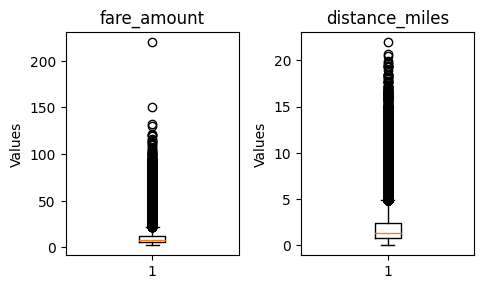

In [ ]:
#check the outlier from Boxplot

# Select columns for box plots
numerical_columns = ['fare_amount','distance_miles']

# Create a box plot for each column
plt.figure(figsize=(12, 8))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(3, 5, i)
    plt.boxplot(uber2[column])
    plt.title(column)
    plt.ylabel('Values')

plt.tight_layout()
plt.show()

In [ ]:
#create new data frame for removing outliers
uber3 = uber2.loc[~((uber2['distance_miles']>4.927) | (uber2['fare_amount']>22.25))]

uber3.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_longitude_grid,pickup_latitude_grid,big_pickup_longitude_grid,big_pickup_latitude_grid,distance_miles,pickup_year
count,173006.000000,173006.000000,173006.000000,173006.000000,173006.000000,173006.000000,173006.000000,173006.000000,173006.000000,173006.000000,173006.000000,173006.000000
mean,8.819266,-73.980445,40.752140,-73.978918,40.752220,1.688242,-73.975893,40.756647,-73.940432,40.786588,1.511416,2011.719091
std,3.953920,0.020625,0.023355,0.021870,0.025362,1.304980,0.020817,0.023446,0.038225,0.036525,1.000954,1.860318
min,2.500000,-74.243432,40.498988,-74.257692,40.486242,1.000000,-74.236500,40.504500,-74.212500,40.537500,0.030153,2009.000000
25%,5.700000,-73.992578,40.737352,-73.991908,40.737152,1.000000,-73.984500,40.738500,-73.987500,40.762500,0.757001,2010.000000
50%,8.000000,-73.982555,40.753235,-73.981435,40.753829,1.000000,-73.975500,40.756500,-73.912500,40.762500,1.234364,2012.000000
75%,11.000000,-73.970580,40.766787,-73.968716,40.767499,2.000000,-73.966500,40.774500,-73.912500,40.837500,2.012631,2013.000000
max,22.200000,-73.702735,40.917048,-73.700650,40.914887,6.000000,-73.696500,40.918500,-73.687500,40.987500,4.926994,2015.000000


In [ ]:
#checking the values after outlier removal
uber3.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 173006 entries, 0 to 185317
Data columns (total 21 columns):
 #   Column                     Non-Null Count   Dtype              
---  ------                     --------------   -----              
 0   order_id                   173006 non-null  object             
 1   fare_amount                173006 non-null  float64            
 2   pickup_datetime            173006 non-null  datetime64[ns, UTC]
 3   pickup_longitude           173006 non-null  float64            
 4   pickup_latitude            173006 non-null  float64            
 5   dropoff_longitude          173006 non-null  float64            
 6   dropoff_latitude           173006 non-null  float64            
 7   passenger_count            173006 non-null  int64              
 8   pickup_longitude_grid      173006 non-null  float64            
 9   pickup_latitude_grid       173006 non-null  float64            
 10  big_pickup_longitude_grid  173006 non-null  float64     

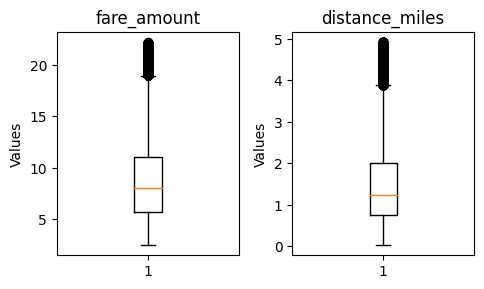

In [ ]:
#check the boxplot after outliers removal

# choosing columns for box plots
numerical_columns = ['fare_amount','distance_miles']

# Create a box plot for each choosen column
plt.figure(figsize=(12, 8))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(3, 5, i)
    plt.boxplot(uber3[column])
    plt.title(column)
    plt.ylabel('Values')

plt.tight_layout()
plt.show()

In [ ]:
#COMPARATION BEFORE AFTER ADDITIONAL DATA CLEANING = NUMBER OF ROW
173006 / 200000

0.86503

In [ ]:
uber3_before_regression = uber3.copy()

In [ ]:
uber3_before_regression.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 173006 entries, 0 to 185317
Data columns (total 21 columns):
 #   Column                     Non-Null Count   Dtype              
---  ------                     --------------   -----              
 0   order_id                   173006 non-null  object             
 1   fare_amount                173006 non-null  float64            
 2   pickup_datetime            173006 non-null  datetime64[ns, UTC]
 3   pickup_longitude           173006 non-null  float64            
 4   pickup_latitude            173006 non-null  float64            
 5   dropoff_longitude          173006 non-null  float64            
 6   dropoff_latitude           173006 non-null  float64            
 7   passenger_count            173006 non-null  int64              
 8   pickup_longitude_grid      173006 non-null  float64            
 9   pickup_latitude_grid       173006 non-null  float64            
 10  big_pickup_longitude_grid  173006 non-null  float64     

In [ ]:
uber3_before_regression[['pickup_datetime','pickup_date']].head()

,pickup_datetime,pickup_date
0,2015-05-07 19:52:06+00:00,2015-05-07
1,2009-07-17 20:04:56+00:00,2009-07-17
2,2009-08-24 21:45:00+00:00,2009-08-24
3,2009-06-26 08:22:21+00:00,2009-06-26
4,2014-08-28 17:47:00+00:00,2014-08-28


In [ ]:
uber3_before_regression.drop('pickup_datetime', axis=1, inplace=True)


In [ ]:
uber3_before_regression.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 173006 entries, 0 to 185317
Data columns (total 20 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   order_id                   173006 non-null  object        
 1   fare_amount                173006 non-null  float64       
 2   pickup_longitude           173006 non-null  float64       
 3   pickup_latitude            173006 non-null  float64       
 4   dropoff_longitude          173006 non-null  float64       
 5   dropoff_latitude           173006 non-null  float64       
 6   passenger_count            173006 non-null  int64         
 7   pickup_longitude_grid      173006 non-null  float64       
 8   pickup_latitude_grid       173006 non-null  float64       
 9   big_pickup_longitude_grid  173006 non-null  float64       
 10  big_pickup_latitude_grid   173006 non-null  float64       
 11  approx_pickup_area         173006 non-null  object  

In [ ]:
##if you want make the regression from excel :

#output_file = 'uber3_before_regression.xlsx'  # Replace 'output.xlsx' with your desired file name and path

#uber3_before_regression.to_excel(output_file, index=False)  # Setting 'index=False' removes the index column in the Excel file

#LINEAR REGRESSION ANALYSIS

## DATA PREPARATION BEFORE LINEAR REGRESSION

In [ ]:
#filter the data for >2013 only, so we can do the analysis with more relevant data
uber3 = uber3.loc[uber3['pickup_year'] >= 2013]
uber3.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 64127 entries, 0 to 185317
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   order_id                   64127 non-null  object             
 1   fare_amount                64127 non-null  float64            
 2   pickup_datetime            64127 non-null  datetime64[ns, UTC]
 3   pickup_longitude           64127 non-null  float64            
 4   pickup_latitude            64127 non-null  float64            
 5   dropoff_longitude          64127 non-null  float64            
 6   dropoff_latitude           64127 non-null  float64            
 7   passenger_count            64127 non-null  int64              
 8   pickup_longitude_grid      64127 non-null  float64            
 9   pickup_latitude_grid       64127 non-null  float64            
 10  big_pickup_longitude_grid  64127 non-null  float64            
 11  b

In [ ]:
#choosing the related columns to do linearregression
uber_regression = uber3[['fare_amount','passenger_count','approx_pickup_area','distance_miles','hour_group','pickup_day']].copy()
uber_regression.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 64127 entries, 0 to 185317
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fare_amount         64127 non-null  float64
 1   passenger_count     64127 non-null  int64  
 2   approx_pickup_area  64127 non-null  object 
 3   distance_miles      64127 non-null  float64
 4   hour_group          64127 non-null  object 
 5   pickup_day          64127 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 3.4+ MB


In [ ]:
#seeing the categorical columns to encode
categorical_columns = uber_regression.select_dtypes(include='object').columns.to_list()
categorical_columns

['approx_pickup_area', 'hour_group', 'pickup_day']

In [ ]:
#encoding the categorical columns
uber_regression = pd.get_dummies(uber_regression, columns = categorical_columns)

#check teh result of encoding
uber_regression.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 64127 entries, 0 to 185317
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   fare_amount                    64127 non-null  float64
 1   passenger_count                64127 non-null  int64  
 2   distance_miles                 64127 non-null  float64
 3   approx_pickup_area_bronx       64127 non-null  uint8  
 4   approx_pickup_area_manhattan   64127 non-null  uint8  
 5   approx_pickup_area_other_area  64127 non-null  uint8  
 6   approx_pickup_area_queens      64127 non-null  uint8  
 7   hour_group_00.00-03.00         64127 non-null  uint8  
 8   hour_group_03.00-06.00         64127 non-null  uint8  
 9   hour_group_06.00-09.00         64127 non-null  uint8  
 10  hour_group_09.00-12.00         64127 non-null  uint8  
 11  hour_group_12.00-15.00         64127 non-null  uint8  
 12  hour_group_15.00-18.00         64127 non-null

In [ ]:
uber_regression.sum().round(2)

fare_amount                      617315.53
passenger_count                  108926.00
distance_miles                    95025.79
approx_pickup_area_bronx          19570.00
approx_pickup_area_manhattan      23113.00
approx_pickup_area_other_area      2110.00
approx_pickup_area_queens         19334.00
hour_group_00.00-03.00             5657.00
hour_group_03.00-06.00             2207.00
hour_group_06.00-09.00             6613.00
hour_group_09.00-12.00             8991.00
hour_group_12.00-15.00             9635.00
hour_group_15.00-18.00             8561.00
hour_group_18.00-21.00            11896.00
hour_group_21.00-00.00            10567.00
pickup_day_Friday                  9922.00
pickup_day_Monday                  8112.00
pickup_day_Saturday                9940.00
pickup_day_Sunday                  8479.00
pickup_day_Thursday                9462.00
pickup_day_Tuesday                 8920.00
pickup_day_Wednesday               9292.00
dtype: float64

In [ ]:
#drop one of each encoded columns group with highest frequency, because if we dont drop it the VIF will detect multicolinearity

columns_drop = ['approx_pickup_area_manhattan','hour_group_18.00-21.00','pickup_day_Friday']
uber_regression = uber_regression.drop(columns=columns_drop)
uber_regression.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 64127 entries, 0 to 185317
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   fare_amount                    64127 non-null  float64
 1   passenger_count                64127 non-null  int64  
 2   distance_miles                 64127 non-null  float64
 3   approx_pickup_area_bronx       64127 non-null  uint8  
 4   approx_pickup_area_other_area  64127 non-null  uint8  
 5   approx_pickup_area_queens      64127 non-null  uint8  
 6   hour_group_00.00-03.00         64127 non-null  uint8  
 7   hour_group_03.00-06.00         64127 non-null  uint8  
 8   hour_group_06.00-09.00         64127 non-null  uint8  
 9   hour_group_09.00-12.00         64127 non-null  uint8  
 10  hour_group_12.00-15.00         64127 non-null  uint8  
 11  hour_group_15.00-18.00         64127 non-null  uint8  
 12  hour_group_21.00-00.00         64127 non-null

In [ ]:
##if you want make the regression from excel :

#output_file = 'uber_regression.xlsx'  # Replace 'output.xlsx' with your desired file name and path

#uber_regression.to_excel(output_file, index=False)  # Setting 'index=False' removes the index column in the Excel file

In [ ]:
#make new dataframes = x for features, y for target
x= uber_regression.copy()
x= uber_regression.drop(columns='fare_amount')
y= uber_regression['fare_amount'].copy()

#check the x dataframe (features)
x.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 64127 entries, 0 to 185317
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   passenger_count                64127 non-null  int64  
 1   distance_miles                 64127 non-null  float64
 2   approx_pickup_area_bronx       64127 non-null  uint8  
 3   approx_pickup_area_other_area  64127 non-null  uint8  
 4   approx_pickup_area_queens      64127 non-null  uint8  
 5   hour_group_00.00-03.00         64127 non-null  uint8  
 6   hour_group_03.00-06.00         64127 non-null  uint8  
 7   hour_group_06.00-09.00         64127 non-null  uint8  
 8   hour_group_09.00-12.00         64127 non-null  uint8  
 9   hour_group_12.00-15.00         64127 non-null  uint8  
 10  hour_group_15.00-18.00         64127 non-null  uint8  
 11  hour_group_21.00-00.00         64127 non-null  uint8  
 12  pickup_day_Monday              64127 non-null

In [ ]:
#check the y data frame
y.info()

<class 'pandas.core.series.Series'>
Int64Index: 64127 entries, 0 to 185317
Series name: fare_amount
Non-Null Count  Dtype  
--------------  -----  
64127 non-null  float64
dtypes: float64(1)
memory usage: 1002.0 KB


In [ ]:
#split X and Y to training and test

x_training, x_test, y_training, y_test = train_test_split(x,y,test_size = 0.2, random_state=10000)

In [ ]:
# Check split result
for df in [x_training, x_test, y_training, y_test]:
  print(df.shape)

(51301, 18)
(12826, 18)
(51301,)
(12826,)


## CHECK CORRELATION AND VIF

In [ ]:
#select the rows for corellation checking
corr_column = x_training.select_dtypes(include=[np.number]).columns.to_list()
corr_column

['passenger_count',
 'distance_miles',
 'approx_pickup_area_bronx',
 'approx_pickup_area_other_area',
 'approx_pickup_area_queens',
 'hour_group_00.00-03.00',
 'hour_group_03.00-06.00',
 'hour_group_06.00-09.00',
 'hour_group_09.00-12.00',
 'hour_group_12.00-15.00',
 'hour_group_15.00-18.00',
 'hour_group_21.00-00.00',
 'pickup_day_Monday',
 'pickup_day_Saturday',
 'pickup_day_Sunday',
 'pickup_day_Thursday',
 'pickup_day_Tuesday',
 'pickup_day_Wednesday']

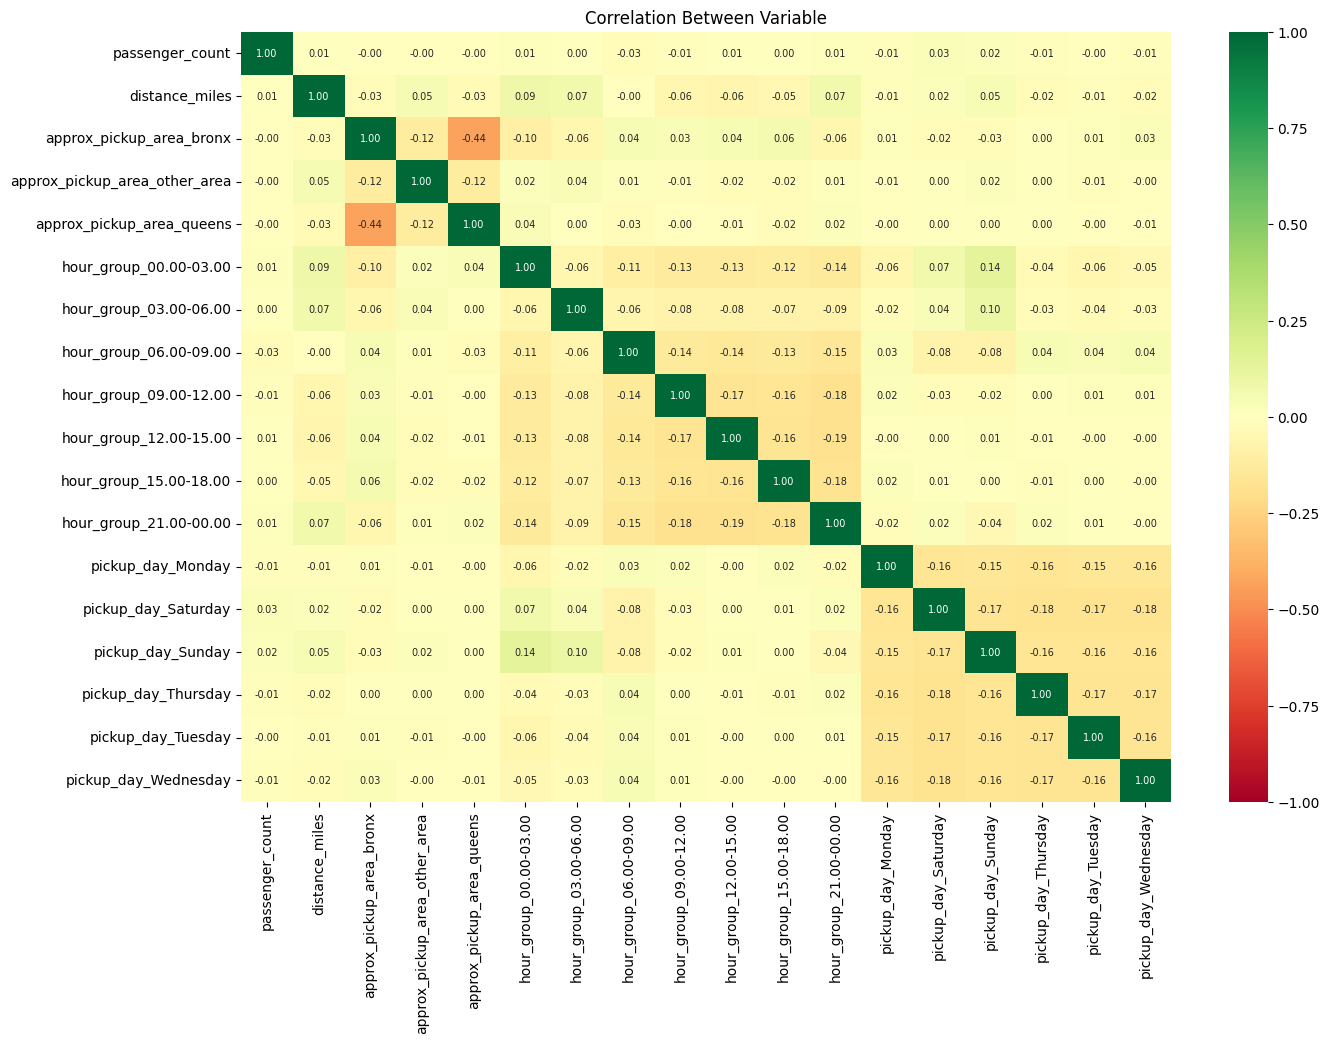

In [ ]:
#see the correlation in heatmap

fig = plt.figure(figsize=(15,10))

ax = fig.add_subplot(1, 1, 1)
ax.set_title('Correlation Between Variable')

sns.heatmap(x_training[corr_column].corr(),vmin=-1,
            vmax=1,cmap='RdYlGn',annot=True,
            annot_kws={"fontsize":7}, fmt=",.2f")

plt.show()

In [ ]:
#for checking the VIF
x_train_with_const = sm.add_constant(x_training)


In [ ]:
#make VIF data frame

vif = pd.DataFrame()
vif["Feature"] = x_train_with_const.columns
vif["VIF"] = [variance_inflation_factor(x_train_with_const.values, i) for i in range(x_train_with_const.shape[1])]

vif

,Feature,VIF
0,const,16.620575
1,passenger_count,1.002206
2,distance_miles,1.030399
3,approx_pickup_area_bronx,1.308141
4,approx_pickup_area_other_area,1.059341
5,approx_pickup_area_queens,1.286571
6,hour_group_00.00-03.00,1.397269
7,hour_group_03.00-06.00,1.173645
8,hour_group_06.00-09.00,1.408430
9,hour_group_09.00-12.00,1.513543


##MAKE AND EVALUATE THE MODEL

In [ ]:
#name the model
lin_reg = LinearRegression()

In [ ]:
#make the model by fitting it to training data frames
lin_reg.fit(x_training,y_training)

LinearRegression()

In [ ]:
#evaluate the model

# Predict the model on the x test
y_pred = lin_reg.predict(x_test)

# Calculate R-squared by comparing the prediction in x test to y test
r_squared = r2_score(y_test, y_pred)
print("R-squared:", r_squared)

R-squared: 0.7179731161231568


In [ ]:
#to see the coeffients for each features and the intercept of the target
print("intercept :", lin_reg.intercept_)

intercept : 4.387780183396706


In [ ]:
print('coef_value :', lin_reg.coef_)

coef_value : [ 0.02920825  3.79210374 -0.43393254 -0.12778398 -0.04624315 -0.7506739
 -0.99350716 -0.36281946  0.50238832  0.65464704  0.40903966 -0.54154197
 -0.4834133  -0.45247479 -0.73687102 -0.04383731 -0.17389447 -0.08191454]


In [ ]:
#put the coefficients, intercept, and standard deviation in one data frame

coef_dict = {'features':x.columns, 'coef_value':lin_reg.coef_, 'std_dev_x':x_training.std(), 'std_dev_y':y_training.std()}

coef = pd.DataFrame(coef_dict, columns=['features','coef_value','std_dev_x','std_dev_y',])
coef = coef.reset_index(drop=True)
coef

,features,coef_value,std_dev_x,std_dev_y
0,passenger_count,0.029208,1.369621,4.26901
1,distance_miles,3.792104,0.969936,4.26901
2,approx_pickup_area_bronx,-0.433933,0.459983,4.26901
3,approx_pickup_area_other_area,-0.127784,0.180213,4.26901
4,approx_pickup_area_queens,-0.046243,0.459265,4.26901
5,hour_group_00.00-03.00,-0.750674,0.283652,4.26901
6,hour_group_03.00-06.00,-0.993507,0.183952,4.26901
7,hour_group_06.00-09.00,-0.362819,0.304114,4.26901
8,hour_group_09.00-12.00,0.502388,0.346623,4.26901
9,hour_group_12.00-15.00,0.654647,0.356613,4.26901


Pricing Model =

intercept + (coeffisien1*feature1) + (coeffisien2*feature2) + ..... + (coeffisien(n)*feature(n)) +


In [ ]:
#make new column of standardized coefficient to see the highly impacted independent variables
coef['standardized_coef'] = coef['coef_value'] * (coef['std_dev_x'] / coef['std_dev_y'])
coef

,features,coef_value,std_dev_x,std_dev_y,standardized_coef
0,passenger_count,0.029208,1.369621,4.26901,0.009371
1,distance_miles,3.792104,0.969936,4.26901,0.861581
2,approx_pickup_area_bronx,-0.433933,0.459983,4.26901,-0.046756
3,approx_pickup_area_other_area,-0.127784,0.180213,4.26901,-0.005394
4,approx_pickup_area_queens,-0.046243,0.459265,4.26901,-0.004975
5,hour_group_00.00-03.00,-0.750674,0.283652,4.26901,-0.049878
6,hour_group_03.00-06.00,-0.993507,0.183952,4.26901,-0.042810
7,hour_group_06.00-09.00,-0.362819,0.304114,4.26901,-0.025846
8,hour_group_09.00-12.00,0.502388,0.346623,4.26901,0.040792
9,hour_group_12.00-15.00,0.654647,0.356613,4.26901,0.054686


In [ ]:
##if you want make the regression from excel :

output_file = 'coef.xlsx'  # Replace 'output.xlsx' with your desired file name and path

coef.to_excel(output_file, index=False)  # Setting 'index=False' removes the index column in the Excel file

#EXISTING PRICING EVALUATION

In [ ]:
#make new data frame
uber4 = uber3.copy()
uber4.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 64127 entries, 0 to 185317
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   order_id                   64127 non-null  object             
 1   fare_amount                64127 non-null  float64            
 2   pickup_datetime            64127 non-null  datetime64[ns, UTC]
 3   pickup_longitude           64127 non-null  float64            
 4   pickup_latitude            64127 non-null  float64            
 5   dropoff_longitude          64127 non-null  float64            
 6   dropoff_latitude           64127 non-null  float64            
 7   passenger_count            64127 non-null  int64              
 8   pickup_longitude_grid      64127 non-null  float64            
 9   pickup_latitude_grid       64127 non-null  float64            
 10  big_pickup_longitude_grid  64127 non-null  float64            
 11  b

In [ ]:
uber4['fare_amount'].sum()

617315.53

In [ ]:
#based on intercept
base_fare = 4.387

##PLACE

In [ ]:
#make a new column consist of the pricing for each variable (base fare + (coefficient * value))
uber4.loc[(uber4['approx_pickup_area'] == 'bronx'), 'place_evaluation'] = base_fare + (-0.433*1)
uber4.loc[(uber4['approx_pickup_area'] == 'queens'), 'place_evaluation'] = base_fare + (-0.046*1)
uber4.loc[(uber4['approx_pickup_area'] == 'other_area'), 'place_evaluation'] = base_fare + (-0.127*1)
uber4.loc[(uber4['approx_pickup_area'] == 'manhattan'), 'place_evaluation'] = base_fare

In [ ]:
#check the average of the pricing of each variable
fare_avg_byplace = uber4.groupby('approx_pickup_area')['place_evaluation'].mean().sort_values(ascending=False)
fare_avg_byplace

approx_pickup_area
manhattan     4.387
queens        4.341
other_area    4.260
bronx         3.954
Name: place_evaluation, dtype: float64

In [ ]:
#evaluate the pricing by compare it to the count of each variable
uber4['approx_pickup_area'].value_counts()

manhattan     23113
bronx         19570
queens        19334
other_area     2110
Name: approx_pickup_area, dtype: int64

##TIME

In [ ]:
#make a new column consist of the pricing for each variable (base fare + (coefficient * value))
uber4.loc[(uber4['hour_group'] == '00.00-03.00'), 'time_evaluation'] = base_fare + (-0.750*1)
uber4.loc[(uber4['hour_group'] == '03.00-06.00'), 'time_evaluation'] = base_fare + (-0.993*1)
uber4.loc[(uber4['hour_group'] == '06.00-09.00'), 'time_evaluation'] = base_fare + (-0.362*1)
uber4.loc[(uber4['hour_group'] == '09.00-12.00'), 'time_evaluation'] = base_fare + (0.502*1)
uber4.loc[(uber4['hour_group'] == '12.00-15.00'), 'time_evaluation'] = base_fare + (0.654*1)
uber4.loc[(uber4['hour_group'] == '15.00-18.00'), 'time_evaluation'] = base_fare + (0.409*1)
uber4.loc[(uber4['hour_group'] == '18.00-21.00'), 'time_evaluation'] = base_fare
uber4.loc[(uber4['hour_group'] == '21.00-00.00'), 'time_evaluation'] = base_fare + (-0.541*1)

In [ ]:
#check the average of the pricing of each variable
fare_avg_bytime = uber4.groupby('hour_group')['time_evaluation'].mean().sort_values(ascending=False)
fare_avg_bytime

hour_group
12.00-15.00    5.041
09.00-12.00    4.889
15.00-18.00    4.796
18.00-21.00    4.387
06.00-09.00    4.025
21.00-00.00    3.846
00.00-03.00    3.637
03.00-06.00    3.394
Name: time_evaluation, dtype: float64

In [ ]:
#evaluate the pricing by compare it to the count of each variable
uber4['hour_group'].value_counts()

18.00-21.00    11896
21.00-00.00    10567
12.00-15.00     9635
09.00-12.00     8991
15.00-18.00     8561
06.00-09.00     6613
00.00-03.00     5657
03.00-06.00     2207
Name: hour_group, dtype: int64

##PASSENGER COUNT

In [ ]:
#make a new column consist of the pricing for the variable (base fare + (coefficient * value))
uber4['passenger_evaluation'] = base_fare + (0.029*1)

In [ ]:
#check the average of the pricing of each value
fare_avg_bypassenger = uber4.groupby('passenger_count')['passenger_evaluation'].mean().sort_values(ascending=False)
fare_avg_bypassenger

passenger_count
1    4.416
2    4.416
3    4.416
4    4.416
5    4.416
6    4.416
Name: passenger_evaluation, dtype: float64

In [ ]:
#evaluate the pricing by compare it to the count of each value
uber4['passenger_count'].value_counts()

1    45249
2     8809
5     3535
3     2750
6     2499
4     1285
Name: passenger_count, dtype: int64

##DAY

In [ ]:
#make a new column consist of the pricing for each variable (base fare + (coefficient * value))
uber4.loc[(uber4['pickup_day'] == 'Monday'), 'day_evaluation'] = base_fare + (-0.483*1)
uber4.loc[(uber4['pickup_day'] == 'Tuesday'), 'day_evaluation'] = base_fare + (-0.173*1)
uber4.loc[(uber4['pickup_day'] == 'Wednesday'), 'day_evaluation'] = base_fare + (-0.081*1)
uber4.loc[(uber4['pickup_day'] == 'Thursday'), 'day_evaluation'] = base_fare + (-0.043*1)
uber4.loc[(uber4['pickup_day'] == 'Friday'), 'day_evaluation'] = base_fare
uber4.loc[(uber4['pickup_day'] == 'Saturday'), 'day_evaluation'] = base_fare + (-0.452*1)
uber4.loc[(uber4['pickup_day'] == 'Sunday'), 'day_evaluation'] = base_fare + (-0.736*1)

In [ ]:
#check the average of the pricing of each variable
uber4['pickup_day'].value_counts()

Saturday     9940
Friday       9922
Thursday     9462
Wednesday    9292
Tuesday      8920
Sunday       8479
Monday       8112
Name: pickup_day, dtype: int64

In [ ]:
#check the average of the pricing of each variable (now we added AM/PM to the evaluation)
fare_avg_byday = uber4.groupby(['pickup_day','time_group'])['day_evaluation'].sum().sort_values(ascending=False)
fare_avg_byday

pickup_day  time_group
Friday      PM            27506.490
Thursday    PM            26255.136
Wednesday   PM            25607.782
Saturday    PM            25254.830
Tuesday     PM            24647.686
Monday      PM            20601.408
Sunday      PM            17721.954
Friday      AM            16021.324
Thursday    AM            14847.792
Wednesday   AM            14403.570
Saturday    AM            13859.070
Sunday      AM            13234.875
Tuesday     AM            12941.194
Monday      AM            11067.840
Name: day_evaluation, dtype: float64

In [ ]:
#evaluate the pricing by compare it to the count of each value
uber4[['pickup_day','time_group']].value_counts()

pickup_day  time_group
Saturday    PM            6418
Friday      PM            6270
Thursday    PM            6044
Wednesday   PM            5947
Tuesday     PM            5849
Monday      PM            5277
Sunday      PM            4854
Friday      AM            3652
Sunday      AM            3625
Saturday    AM            3522
Thursday    AM            3418
Wednesday   AM            3345
Tuesday     AM            3071
Monday      AM            2835
dtype: int64

##DISTANCE


In [ ]:
#make a new column consist of the pricing for the variable (base fare + (coefficient * value))
uber4['distance_evaluation'] = base_fare + (3.792*1)

In [ ]:
#check the average of the pricing of each value
uber4['distance_evaluation'].mean()

8.179

In [ ]:
uber4.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 64127 entries, 0 to 185317
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   order_id                   64127 non-null  object             
 1   fare_amount                64127 non-null  float64            
 2   pickup_datetime            64127 non-null  datetime64[ns, UTC]
 3   pickup_longitude           64127 non-null  float64            
 4   pickup_latitude            64127 non-null  float64            
 5   dropoff_longitude          64127 non-null  float64            
 6   dropoff_latitude           64127 non-null  float64            
 7   passenger_count            64127 non-null  int64              
 8   pickup_longitude_grid      64127 non-null  float64            
 9   pickup_latitude_grid       64127 non-null  float64            
 10  big_pickup_longitude_grid  64127 non-null  float64            
 11  b

In [ ]:
#drop the date time with timezone

uber4.drop('pickup_datetime', axis=1, inplace=True)

##if you want make the regression from excel :

#output_file = 'uber4.xlsx'  # Replace 'output.xlsx' with your desired file name and path

#uber4.to_excel(output_file, index=False)  # Setting 'index=False' removes the index column in the Excel file

#OPTIMIZED PRICING MODEL

In [ ]:
#make new data frame
uber5 = uber3.copy()
uber5.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 64127 entries, 0 to 185317
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   order_id                   64127 non-null  object             
 1   fare_amount                64127 non-null  float64            
 2   pickup_datetime            64127 non-null  datetime64[ns, UTC]
 3   pickup_longitude           64127 non-null  float64            
 4   pickup_latitude            64127 non-null  float64            
 5   dropoff_longitude          64127 non-null  float64            
 6   dropoff_latitude           64127 non-null  float64            
 7   passenger_count            64127 non-null  int64              
 8   pickup_longitude_grid      64127 non-null  float64            
 9   pickup_latitude_grid       64127 non-null  float64            
 10  big_pickup_longitude_grid  64127 non-null  float64            
 11  b

In [ ]:
uber3['fare_amount'].sum()

617315.53

In [ ]:
#highfare, normal, and discount multiplier for new pricing model
base_fare = 4.387
high_fare = base_fare * 0.20
normal_fare = base_fare * 0
discount = base_fare * (-0.20)

##DISTANCE

In [ ]:
#make a new column to determine new pricing with new distance pricing model
uber5['distance_pricing'] = uber5['distance_miles']*3.792

##PLACE

In [ ]:
#make a new column to determine new pricing with new place pricing model
uber5.loc[(uber5['approx_pickup_area'] == 'manhattan'), 'place_pricing'] = high_fare

uber5.loc[(uber5['approx_pickup_area'] == 'queens') | (uber5['approx_pickup_area'] == 'bronx'), 'place_pricing'] = normal_fare

uber5.loc[(uber5['approx_pickup_area'] == 'other_area'), 'place_pricing'] = discount

##TIME

In [ ]:
#make a new column to determine new pricing with new time pricing model
uber5.loc[(uber5['hour_group'] == '18.00-21.00') | (uber5['hour_group'] == '21.00-00.00'), 'time_pricing'] = high_fare

uber5.loc[(uber5['hour_group'] == '06.00-09.00') | (uber5['hour_group'] == '09.00-12.00') |
          (uber5['hour_group'] == '12.00-15.00') | (uber5['hour_group'] == '15.00-18.00'), 'time_pricing'] = normal_fare

uber5.loc[(uber5['hour_group'] == '00.00-03.00') | (uber5['hour_group'] == '03.00-06.00'), 'time_pricing'] = discount

##PASSENGER COUNT

In [ ]:
#make a new column to determine new pricing with new passenger pricing model
uber5.loc[(uber5['passenger_count'] <= 4),'passenger_pricing'] = normal_fare

uber5.loc[(uber5['passenger_count'] > 4),'passenger_pricing'] = high_fare

##DAY

In [ ]:
#make a new column to determine new pricing with new day pricing model
uber5.loc[((uber5['pickup_day'] == 'Wednesday') & (uber5['time_group'] == 'PM')) |
          ((uber5['pickup_day'] == 'Thursday') & (uber5['time_group'] == 'PM')) |
          ((uber5['pickup_day'] == 'Friday') & (uber5['time_group'] == 'PM')) |
          ((uber5['pickup_day'] == 'Saturday') & (uber5['time_group'] == 'PM'))
          , 'day_pricing'] = high_fare

uber5.loc[((uber5['pickup_day'] == 'Monday') & (uber5['time_group'] == 'PM')) |
          ((uber5['pickup_day'] == 'Tuesday') & (uber5['time_group'] == 'PM')) |
          ((uber5['pickup_day'] == 'Friday') & (uber5['time_group'] == 'AM')) |
          ((uber5['pickup_day'] == 'Saturday') & (uber5['time_group'] == 'AM')) |
          ((uber5['pickup_day'] == 'Sunday') & (uber5['time_group'] == 'AM')) |
          ((uber5['pickup_day'] == 'Sunday') & (uber5['time_group'] == 'PM'))
          , 'day_pricing'] = 4.052 * normal_fare


uber5.loc[((uber5['pickup_day'] == 'Monday') & (uber5['time_group'] == 'AM')) |
          ((uber5['pickup_day'] == 'Tuesday') & (uber5['time_group'] == 'AM')) |
          ((uber5['pickup_day'] == 'Wednesday') & (uber5['time_group'] == 'AM')) |
          ((uber5['pickup_day'] == 'Thursday') & (uber5['time_group'] == 'AM'))
          , 'day_pricing'] = discount


##FINAL OPTIMIZED PRICE

In [ ]:
#make new a column for the total of new optimized pricing model of each independent variable
uber5['optimized_price'] = base_fare + uber5['distance_pricing'] + uber5['place_pricing'] + uber5['time_pricing'] + uber5['passenger_pricing'] + uber5['day_pricing']

In [ ]:
uber5.head()

,order_id,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_longitude_grid,pickup_latitude_grid,...,pickup_year,hour_group,time_group,distance_group,distance_pricing,place_pricing,time_pricing,passenger_pricing,day_pricing,optimized_price
0,24238194,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,-73.9935,40.7385,...,2015,18.00-21.00,PM,short_trip,3.961100,0.8774,0.8774,0.0000,0.8774,10.980300
4,17610152,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,-73.9215,40.7475,...,2014,15.00-18.00,PM,long_trip,10.564742,0.0000,0.0000,0.8774,0.8774,16.706542
10,2205147,6.5,2015-05-22 17:32:27+00:00,-73.974388,40.746952,-73.988586,40.729805,1,-73.9665,40.7475,...,2015,15.00-18.00,PM,long_trip,5.302389,0.0000,0.0000,0.0000,0.8774,10.566789
18,49173512,12.0,2015-03-25 08:58:35+00:00,-73.962532,40.767189,-73.974457,40.753860,1,-73.9575,40.7745,...,2015,06.00-09.00,AM,short_trip,4.218029,0.0000,0.0000,0.0000,-0.8774,7.727629
20,55085966,10.5,2014-02-18 14:26:00+00:00,-73.980022,40.745990,-74.003432,40.759667,1,-73.9755,40.7475,...,2014,12.00-15.00,PM,long_trip,5.874138,0.0000,0.0000,0.0000,0.0000,10.261138


#EVALUATION OF OPTIMIZED PRICING MODEL

In [ ]:
#check the new pricing columns added
uber5.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 64127 entries, 0 to 185317
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   order_id                   64127 non-null  object             
 1   fare_amount                64127 non-null  float64            
 2   pickup_datetime            64127 non-null  datetime64[ns, UTC]
 3   pickup_longitude           64127 non-null  float64            
 4   pickup_latitude            64127 non-null  float64            
 5   dropoff_longitude          64127 non-null  float64            
 6   dropoff_latitude           64127 non-null  float64            
 7   passenger_count            64127 non-null  int64              
 8   pickup_longitude_grid      64127 non-null  float64            
 9   pickup_latitude_grid       64127 non-null  float64            
 10  big_pickup_longitude_grid  64127 non-null  float64            
 11  b

In [ ]:
##ini gausah dipake, nanti malah jadi error
#change the type so we dont see too much decimal from float
#uber5['fare_amount'] = uber5['fare_amount'].astype('int')
#uber5['optimized_price'] = uber5['optimized_price'].astype('int')

In [ ]:
#compare the existing pricing with optimized new pricing model
uber5[['fare_amount','optimized_price']].describe()

,fare_amount,optimized_price
count,64127.000000,64127.000000
mean,9.626453,10.740124
std,4.266098,3.847782
min,2.500000,1.919685
25%,6.500000,7.942609
50%,8.500000,9.877069
75%,12.000000,12.782529
max,22.040000,26.419555


In [ ]:
(10.50/9.37)-1


0.12059765208111006

In [ ]:
#compare the existing pricing EACH YEAR with optimized new pricing model
fare_comparation = uber5.groupby(['pickup_year'])[['fare_amount', 'optimized_price']].sum()
fare_comparation['increasement'] = (fare_comparation['optimized_price']/fare_comparation['fare_amount'])-1
fare_comparation

,fare_amount,optimized_price,increasement
pickup_year,,,
2013,256945.86,290380.292234,0.130122
2014,247094.70,273705.110619,0.107693
2015,113274.97,124646.536569,0.100389


In [ ]:
fare_comparation_total = uber5[['fare_amount','optimized_price']].sum().copy()
fare_comparation_total['increasement'] = (fare_comparation_total['optimized_price']/fare_comparation_total['fare_amount'])-1
fare_comparation_total

fare_amount        617315.530000
optimized_price    688731.939422
increasement            0.115689
dtype: float64

In [ ]:
uber5['fare_amount'].sum()

617315.53

In [ ]:
#drop the date time with timezone

#uber5.drop('pickup_datetime', axis=1, inplace=True)

##if you want make the regression from excel :

output_file = 'uber5.xlsx'  # Replace 'output.xlsx' with your desired file name and path

uber5.to_excel(output_file, index=False)  # Setting 'index=False' removes the index column in the Excel file